In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

df = pd.read_csv("European_Bank_Cleaned_Featured.csv")

print("Dataset shape:", df.shape)

Dataset shape: (10000, 29)


In [2]:
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Age_Group,Balance_Segment,Salary_Segment,Product_Depth_Group,Engagement_Status,Engagement_Profile,High_Value_Customer,High_Value_Disengaged,Customer_Value_Segment,Credit_Card_Status,Engagement_Score,Initial_Retention_Risk,Balance_to_Salary_Ratio,Financial_Segment,Churn_Status
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,36-45,Low Balance,High Salary,Single Product,Active,Active Low-Product,0,0,Standard Value - Engaged,Card Holder,70,Low Risk,0.000000,High Salary - Low Balance,Churned
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,36-45,Medium Balance,High Salary,Single Product,Active,Active Low-Product,0,0,Standard Value - Engaged,Non Card Holder,50,Low Risk,0.744677,High Salary - Low Balance,Retained
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,36-45,Very High Balance,High Salary,3+ Products,Inactive,Inactive Multi-Product,1,1,High Value - Disengaged,Card Holder,50,High Risk,1.401375,High Salary - High Balance,Churned
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,36-45,Low Balance,Medium Salary,Two Products,Inactive,Inactive Multi-Product,0,0,Standard Value - Disengaged,Non Card Holder,30,Medium Risk,0.000000,Low Salary - Low Balance,Retained
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,36-45,High Balance,Medium Salary,Single Product,Active,Active Low-Product,0,0,Standard Value - Engaged,Card Holder,70,Low Risk,1.587055,Low Salary - High Balance,Retained


In [3]:
required_columns = [
    "CustomerId",
    "Balance",
    "EstimatedSalary",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "Exited",
    "Engagement_Status",
    "Engagement_Profile",
    "High_Value_Customer",
    "High_Value_Disengaged"
]

df[required_columns].head()

,CustomerId,Balance,EstimatedSalary,NumOfProducts,HasCrCard,IsActiveMember,Exited,Engagement_Status,Engagement_Profile,High_Value_Customer,High_Value_Disengaged
0,15634602,0.00,101348.88,1,1,1,1,Active,Active Low-Product,0,0
1,15647311,83807.86,112542.58,1,0,1,0,Active,Active Low-Product,0,0
2,15619304,159660.80,113931.57,3,1,0,1,Inactive,Inactive Multi-Product,1,1
3,15701354,0.00,93826.63,2,0,0,0,Inactive,Inactive Multi-Product,0,0
4,15737888,125510.82,79084.10,1,1,1,0,Active,Active Low-Product,0,0


In [4]:
df["Engagement_Profile"].value_counts()

Engagement_Profile
Active Engaged            2588
Active Low-Product        2563
Inactive Disengaged       2521
Inactive Multi-Product    2328
Name: count, dtype: int64

In [5]:
profile_count = (
    df["Engagement_Profile"]
    .value_counts()
    .reset_index()
)

profile_count.columns = [
    "Engagement_Profile",
    "Customer_Count"
]

profile_count

,Engagement_Profile,Customer_Count
0,Active Engaged,2588
1,Active Low-Product,2563
2,Inactive Disengaged,2521
3,Inactive Multi-Product,2328


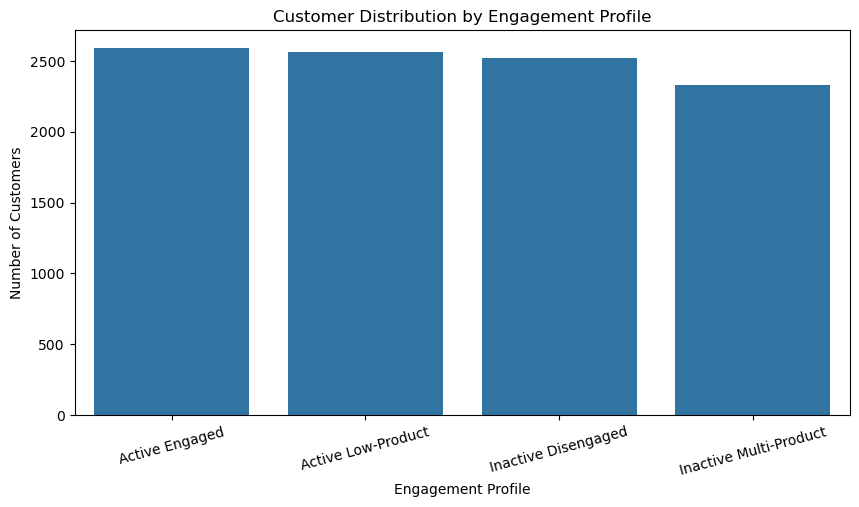

In [6]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=profile_count,
    x="Engagement_Profile",
    y="Customer_Count"
)

plt.title("Customer Distribution by Engagement Profile")
plt.xlabel("Engagement Profile")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

In [7]:
profile_analysis = (
    df.groupby("Engagement_Profile")
    .agg(
        Customers=("CustomerId", "count"),
        Churned=("Exited", "sum"),
        Churn_Rate=("Exited", "mean"),
        Avg_Balance=("Balance", "mean"),
        Avg_Salary=("EstimatedSalary", "mean"),
        Avg_Products=("NumOfProducts", "mean"),
        Avg_Credit_Score=("CreditScore", "mean")
    )
    .reset_index()
)

profile_analysis["Churn_Rate"] = (
    profile_analysis["Churn_Rate"] * 100
)

profile_analysis = profile_analysis.sort_values(
    "Churn_Rate",
    ascending=False
)

profile_analysis.round(2)

,Engagement_Profile,Customers,Churned,Churn_Rate,Avg_Balance,Avg_Salary,Avg_Products,Avg_Credit_Score
2,Inactive Disengaged,2521,924,36.65,98195.89,100856.86,1.00,647.08
1,Active Low-Product,2563,485,18.92,98902.02,98140.10,1.00,651.13
3,Inactive Multi-Product,2328,378,16.24,54326.79,100670.12,2.09,648.94
0,Active Engaged,2588,250,9.66,53071.26,100753.15,2.07,654.72


In [8]:
overall_churn = df["Exited"].mean() * 100

profile_analysis["Churn_vs_Baseline"] = (
    profile_analysis["Churn_Rate"]
    - overall_churn
)

profile_analysis["Risk_Multiple"] = (
    profile_analysis["Churn_Rate"]
    / overall_churn
)

profile_analysis.round(2)

,Engagement_Profile,Customers,Churned,Churn_Rate,Avg_Balance,Avg_Salary,Avg_Products,Avg_Credit_Score,Churn_vs_Baseline,Risk_Multiple
2,Inactive Disengaged,2521,924,36.65,98195.89,100856.86,1.00,647.08,16.28,1.80
1,Active Low-Product,2563,485,18.92,98902.02,98140.10,1.00,651.13,-1.45,0.93
3,Inactive Multi-Product,2328,378,16.24,54326.79,100670.12,2.09,648.94,-4.13,0.80
0,Active Engaged,2588,250,9.66,53071.26,100753.15,2.07,654.72,-10.71,0.47


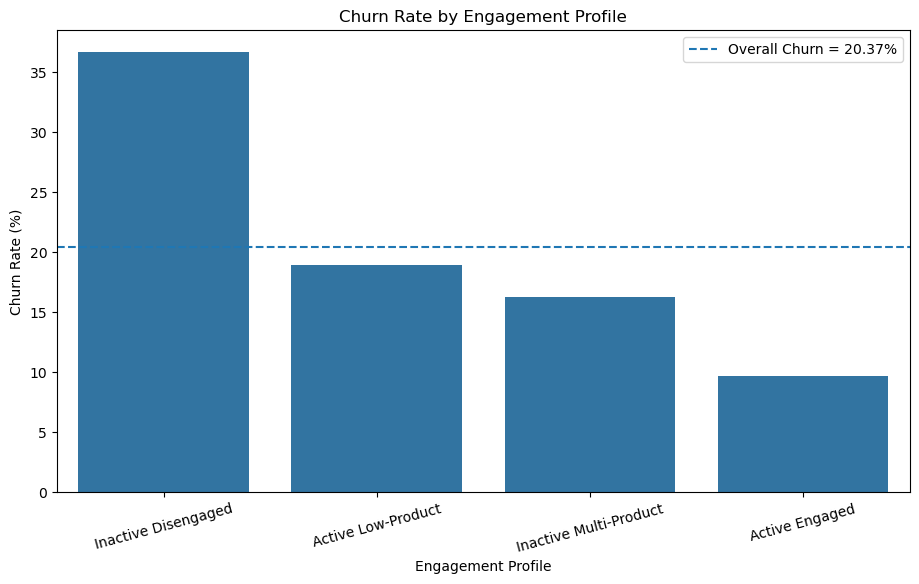

In [9]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=profile_analysis,
    x="Engagement_Profile",
    y="Churn_Rate"
)

plt.axhline(
    overall_churn,
    linestyle="--",
    label=f"Overall Churn = {overall_churn:.2f}%"
)

plt.title("Churn Rate by Engagement Profile")
plt.xlabel("Engagement Profile")
plt.ylabel("Churn Rate (%)")
plt.legend()

plt.xticks(rotation=15)

plt.show()

In [10]:
engagement_summary = (
    df.groupby("Engagement_Status")
    .agg(
        Customers=("CustomerId", "count"),
        Churned=("Exited", "sum"),
        Churn_Rate=("Exited", "mean"),
        Avg_Balance=("Balance", "mean"),
        Avg_Products=("NumOfProducts", "mean")
    )
    .reset_index()
)

engagement_summary["Churn_Rate"] *= 100

engagement_summary.round(2)

,Engagement_Status,Customers,Churned,Churn_Rate,Avg_Balance,Avg_Products
0,Active,5151,735,14.27,75875.42,1.54
1,Inactive,4849,1302,26.85,77134.38,1.52


In [11]:
active_churn = (
    df.loc[df["IsActiveMember"] == 1, "Exited"].mean()
)

inactive_churn = (
    df.loc[df["IsActiveMember"] == 0, "Exited"].mean()
)

engagement_churn_gap = (
    inactive_churn - active_churn
) * 100

print(
    f"Inactive vs Active churn gap: "
    f"{engagement_churn_gap:.2f} percentage points"
)

Inactive vs Active churn gap: 12.58 percentage points


In [12]:
engagement_retention_ratio = (
    inactive_churn / active_churn
)

print(
    "Inactive-to-active churn ratio:",
    round(engagement_retention_ratio, 2)
)

Inactive-to-active churn ratio: 1.88


In [13]:
engagement_product = pd.crosstab(
    df["Engagement_Status"],
    df["Product_Depth_Group"]
)

engagement_product

Product_Depth_Group,3+ Products,Single Product,Two Products
Engagement_Status,,,
Active,142,2563,2446
Inactive,184,2521,2144


In [14]:
engagement_product_churn = (
    df.groupby(
        ["Engagement_Status", "Product_Depth_Group"]
    )["Exited"]
    .mean()
    .mul(100)
    .reset_index(name="Churn_Rate")
)

engagement_product_churn

,Engagement_Status,Product_Depth_Group,Churn_Rate
0,Active,3+ Products,80.281690
1,Active,Single Product,18.923137
2,Active,Two Products,5.560098
3,Inactive,3+ Products,90.217391
4,Inactive,Single Product,36.652122
5,Inactive,Two Products,9.888060


In [15]:
pivot_churn = engagement_product_churn.pivot(
    index="Engagement_Status",
    columns="Product_Depth_Group",
    values="Churn_Rate"
)

pivot_churn

Product_Depth_Group,3+ Products,Single Product,Two Products
Engagement_Status,,,
Active,80.281690,18.923137,5.560098
Inactive,90.217391,36.652122,9.888060


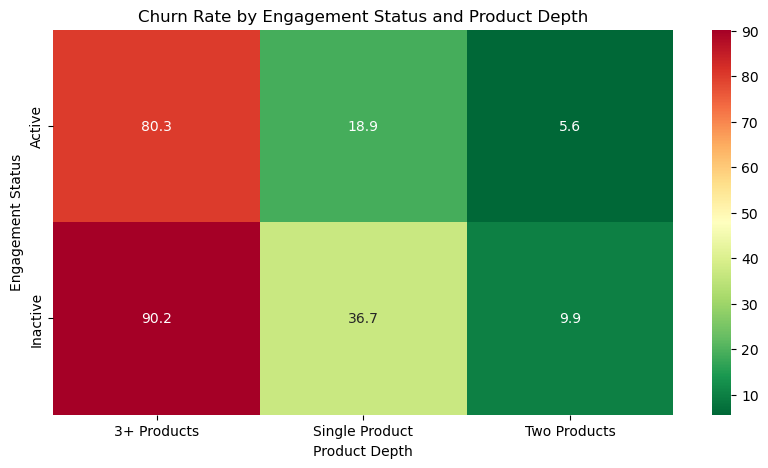

In [16]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    pivot_churn,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r"
)

plt.title(
    "Churn Rate by Engagement Status and Product Depth"
)

plt.xlabel("Product Depth")
plt.ylabel("Engagement Status")

plt.show()

In [17]:
engagement_product_full = (
    df.groupby(
        ["Engagement_Status", "Product_Depth_Group"]
    )
    .agg(
        Customers=("CustomerId", "count"),
        Churned=("Exited", "sum"),
        Churn_Rate=("Exited", "mean"),
        Avg_Balance=("Balance", "mean"),
        Avg_Salary=("EstimatedSalary", "mean")
    )
    .reset_index()
)

engagement_product_full["Churn_Rate"] *= 100

engagement_product_full.round(2)

,Engagement_Status,Product_Depth_Group,Customers,Churned,Churn_Rate,Avg_Balance,Avg_Salary
0,Active,3+ Products,142,114,80.28,74057.29,105663.23
1,Active,Single Product,2563,485,18.92,98902.02,98140.10
2,Active,Two Products,2446,136,5.56,51852.94,100468.10
3,Inactive,3+ Products,184,166,90.22,82498.74,103425.36
4,Inactive,Single Product,2521,924,36.65,98195.89,100856.86
5,Inactive,Two Products,2144,212,9.89,51909.04,100433.66


In [18]:
high_risk_combinations = (
    engagement_product_full
    .sort_values(
        "Churn_Rate",
        ascending=False
    )
)

high_risk_combinations.round(2)

,Engagement_Status,Product_Depth_Group,Customers,Churned,Churn_Rate,Avg_Balance,Avg_Salary
3,Inactive,3+ Products,184,166,90.22,82498.74,103425.36
0,Active,3+ Products,142,114,80.28,74057.29,105663.23
4,Inactive,Single Product,2521,924,36.65,98195.89,100856.86
1,Active,Single Product,2563,485,18.92,98902.02,98140.10
5,Inactive,Two Products,2144,212,9.89,51909.04,100433.66
2,Active,Two Products,2446,136,5.56,51852.94,100468.10


In [19]:
high_risk_combinations[
    [
        "Engagement_Status",
        "Product_Depth_Group",
        "Customers",
        "Churn_Rate",
        "Avg_Balance"
    ]
]

,Engagement_Status,Product_Depth_Group,Customers,Churn_Rate,Avg_Balance
3,Inactive,3+ Products,184,90.217391,82498.736793
0,Active,3+ Products,142,80.281690,74057.294577
4,Inactive,Single Product,2521,36.652122,98195.888413
1,Active,Single Product,2563,18.923137,98902.019317
5,Inactive,Two Products,2144,9.888060,51909.044380
2,Active,Two Products,2446,5.560098,51852.938729


In [20]:
product_exact = (
    df.groupby("NumOfProducts")
    .agg(
        Customers=("CustomerId", "count"),
        Churned=("Exited", "sum"),
        Churn_Rate=("Exited", "mean"),
        Active_Rate=("IsActiveMember", "mean"),
        Avg_Balance=("Balance", "mean")
    )
    .reset_index()
)

product_exact["Churn_Rate"] *= 100
product_exact["Active_Rate"] *= 100

product_exact.round(2)

,NumOfProducts,Customers,Churned,Churn_Rate,Active_Rate,Avg_Balance
0,1,5084,1409,27.71,50.41,98551.87
1,2,4590,348,7.58,53.29,51879.15
2,3,266,220,82.71,42.48,75458.33
3,4,60,60,100.00,48.33,93733.14


In [21]:
three_four = df[
    df["NumOfProducts"].isin([3, 4])
]

three_four[
    [
        "NumOfProducts",
        "IsActiveMember",
        "Balance",
        "EstimatedSalary",
        "Age",
        "Geography",
        "CreditScore",
        "Exited"
    ]
].describe(include="all")

,NumOfProducts,IsActiveMember,Balance,EstimatedSalary,Age,Geography,CreditScore,Exited
count,326.000000,326.000000,326.000000,326.000000,326.000000,326,326.000000,326.000000
unique,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,France,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,133,NaN,NaN
mean,3.184049,0.435583,78821.789571,104400.141503,43.653374,NaN,649.113497,0.858896
std,0.388120,0.496595,62283.191084,55759.764947,10.148108,NaN,96.200413,0.348664
min,3.000000,0.000000,0.000000,3440.470000,21.000000,NaN,358.000000,0.000000
25%,3.000000,0.000000,0.000000,64344.800000,37.000000,NaN,587.250000,1.000000
50%,3.000000,0.000000,101628.675000,103874.670000,43.000000,NaN,650.000000,1.000000
75%,3.000000,1.000000,128743.610000,151150.967500,50.000000,NaN,711.000000,1.000000


In [22]:
three_four["NumOfProducts"].value_counts()

NumOfProducts
3    266
4     60
Name: count, dtype: int64

In [23]:
three_four.groupby(
    ["NumOfProducts", "IsActiveMember"]
)["Exited"].agg(
    ["count", "sum", "mean"]
)

count  sum      mean
NumOfProducts IsActiveMember                      
3             0                 153  135  0.882353
              1                 113   85  0.752212
4             0                  31   31  1.000000
              1                  29   29  1.000000

In [24]:
def final_engagement_segment(row):
    
    if row["NumOfProducts"] >= 3:
        return "Complex / Investigate"
    
    elif row["IsActiveMember"] == 1 and row["NumOfProducts"] >= 2:
        return "Highly Engaged"
    
    elif row["IsActiveMember"] == 1 and row["NumOfProducts"] == 1:
        return "Engaged Growth"
    
    elif row["IsActiveMember"] == 0 and row["NumOfProducts"] >= 2:
        return "Dormant Relationship"
    
    else:
        return "Disengaged Single-Product"

df["Final_Engagement_Segment"] = df.apply(
    final_engagement_segment,
    axis=1
)

In [25]:
df["Final_Engagement_Segment"].value_counts()

Final_Engagement_Segment
Engaged Growth               2563
Disengaged Single-Product    2521
Highly Engaged               2446
Dormant Relationship         2144
Complex / Investigate         326
Name: count, dtype: int64

In [26]:
final_segment_analysis = (
    df.groupby("Final_Engagement_Segment")
    .agg(
        Customers=("CustomerId", "count"),
        Churned=("Exited", "sum"),
        Churn_Rate=("Exited", "mean"),
        Avg_Balance=("Balance", "mean"),
        Avg_Salary=("EstimatedSalary", "mean"),
        Avg_Products=("NumOfProducts", "mean"),
        Active_Rate=("IsActiveMember", "mean")
    )
    .reset_index()
)

final_segment_analysis["Churn_Rate"] *= 100
final_segment_analysis["Active_Rate"] *= 100

final_segment_analysis.round(2)

,Final_Engagement_Segment,Customers,Churned,Churn_Rate,Avg_Balance,Avg_Salary,Avg_Products,Active_Rate
0,Complex / Investigate,326,280,85.89,78821.79,104400.14,3.18,43.56
1,Disengaged Single-Product,2521,924,36.65,98195.89,100856.86,1.00,0.00
2,Dormant Relationship,2144,212,9.89,51909.04,100433.66,2.00,0.00
3,Engaged Growth,2563,485,18.92,98902.02,98140.10,1.00,100.00
4,Highly Engaged,2446,136,5.56,51852.94,100468.10,2.00,100.00


In [27]:
growth_opportunity = df[
    (df["IsActiveMember"] == 1) &
    (df["NumOfProducts"] == 1)
]

print(
    "Active single-product customers:",
    len(growth_opportunity)
)

Active single-product customers: 2563


In [28]:
dormant_relationship = df[
    (df["IsActiveMember"] == 0) &
    (df["NumOfProducts"] >= 2)
]

print(
    "Inactive multi-product customers:",
    len(dormant_relationship)
)

Inactive multi-product customers: 2328


In [29]:
priority_customers = df[
    (df["High_Value_Disengaged"] == 1) |
    (
        (df["IsActiveMember"] == 0) &
        (df["NumOfProducts"] == 1)
    )
]

print(
    "Priority retention customers:",
    len(priority_customers)
)

Priority retention customers: 2940


In [30]:
priority_customers[
    [
        "CustomerId",
        "Balance",
        "EstimatedSalary",
        "NumOfProducts",
        "IsActiveMember",
        "Exited"
    ]
].head(20)

,CustomerId,Balance,EstimatedSalary,NumOfProducts,IsActiveMember,Exited
2,15619304,159660.80,113931.57,3,0,1
16,15737452,132602.88,5097.67,1,0,1
18,15661507,0.00,158684.81,1,0,0
22,15699309,0.00,118913.53,1,0,1
35,15794171,134264.04,27822.99,1,0,1
40,15619360,0.00,70154.22,1,0,0
41,15738148,122522.32,181297.65,1,0,1
43,15755196,131394.56,194365.76,1,0,1
51,15768193,146050.97,86424.57,2,0,0
53,15702298,125561.97,164040.94,1,0,1


In [31]:
strategy_map = {
    "Highly Engaged": "Retain & Reward",
    "Engaged Growth": "Cross-Sell Carefully",
    "Dormant Relationship": "Reactivate",
    "Disengaged Single-Product": "High Priority Retention",
    "Complex / Investigate": "Investigate Product-Churn Pattern"
}

df["Recommended_Strategy"] = (
    df["Final_Engagement_Segment"]
    .map(strategy_map)
)

In [32]:
df[
    [
        "Final_Engagement_Segment",
        "Recommended_Strategy"
    ]
].drop_duplicates()

,Final_Engagement_Segment,Recommended_Strategy
0,Engaged Growth,Cross-Sell Carefully
2,Complex / Investigate,Investigate Product-Churn Pattern
3,Dormant Relationship,Reactivate
6,Highly Engaged,Retain & Reward
16,Disengaged Single-Product,High Priority Retention


In [33]:
df.to_csv(
    "European_Bank_Engagement_Analyzed.csv",
    index=False
)

print(
    "✅ Step 4 dataset saved successfully."
)

✅ Step 4 dataset saved successfully.


In [34]:
final_segment_analysis.to_csv(
    "Engagement_Segment_Summary.csv",
    index=False
)